In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import shap

# 1. Load the data
df = pd.read_csv('creditcard.csv')

# 2. Basic cleaning (same as previous steps)
df = df.drop(['Time'], axis=1)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# 3. Split the data to get X_test
X = df.drop(['Class'], axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. We need a trained model to explain! 
# Let's quickly train a Random Forest on a smaller SMOTE sample so it's fast
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# We limit the depth so the training and SHAP calculations are faster
model_rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model_rf.fit(X_train_smote, y_train_smote)

print("Setup Complete! 'X_test' and 'model_rf' are now defined.")

c:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Setup Complete! 'X_test' and 'model_rf' are now defined.


In [14]:
import shap
import numpy as np
#Take 100 transactions from test data to explain
X_sample = X_test.iloc[:100]
#create the fast tree explainer using our trained random forest
explainer = shap.TreeExplainer(model_rf)
#Calculate the shapley values
shap_values = explainer.shap_values(X_sample)
#Handle the shape difference 
if isinstance(shap_values, list):
    final_shap_values = shap_values[1]
else:
    final_shap_values = shap_values[:, :, 1]

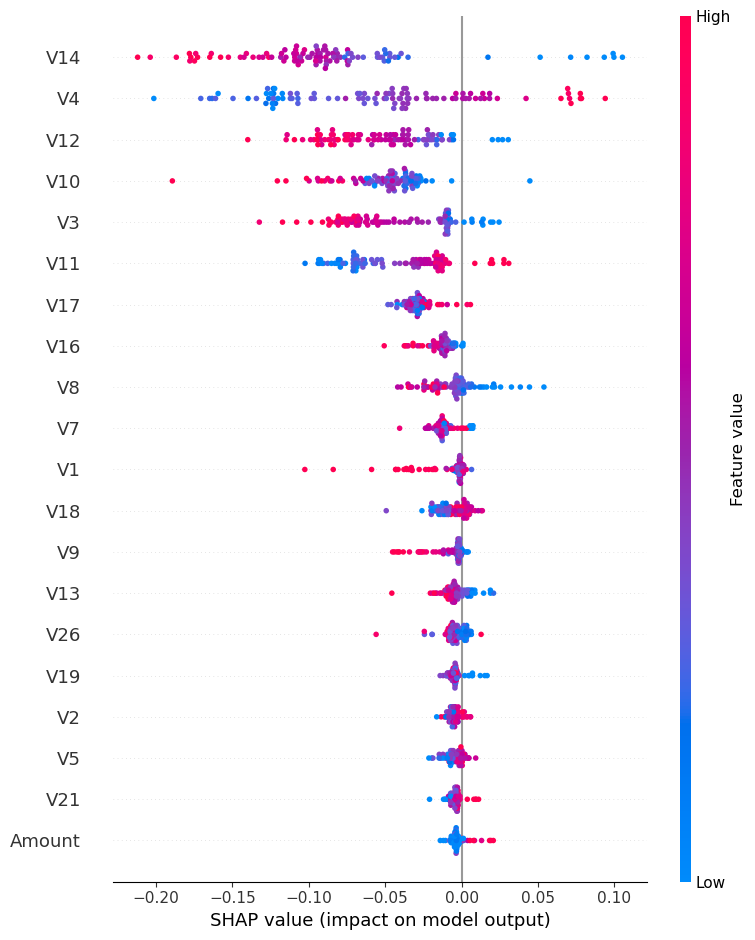

In [18]:
#create a beeswarm plot(Global plot)
shap.summary_plot(final_shap_values, X_sample)

In [16]:
#initialize the javascript for the interactive force plot
shap.initjs()
#Plot 2 - force plot
shap.force_plot(explainer.expected_value[1], final_shap_values[0,:], X_sample.iloc[0,:])


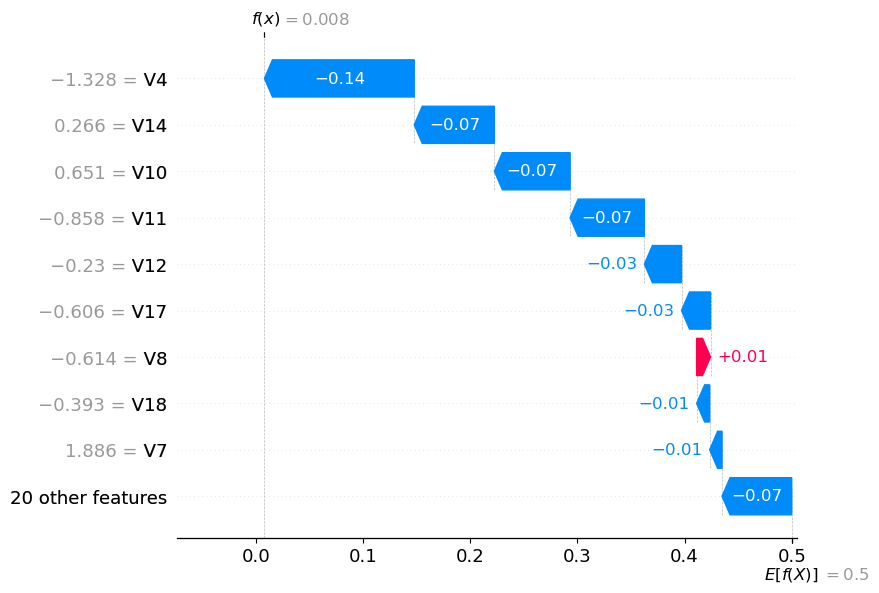

In [17]:
# Plot 3: Waterfall Plot (The Audit Trail) for the first transaction
# We create an 'Explanation' object to format the data for the plot
exp = shap.Explanation(
    values = final_shap_values[0,:],
    base_values = explainer.expected_value[1],
    data = X_sample.iloc[0,:],
    feature_names = X_sample.columns.tolist()

)
shap.plots.waterfall(exp)

In [19]:
import joblib

# This saves the model as a file in your project folder
joblib.dump(model_rf, 'fraud_model.pkl')

# This saves the scaler as a file in your project folder
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']